In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib


In [4]:
# Load feature index
INDEX_FILE = "features/feature_index_w3_s1.csv"

index_df = pd.read_csv(INDEX_FILE)

print("Files:", len(index_df))
index_df.head()


Files: 60


,subject_id,file_id,label_type,feature_path,timestamp_path
0,subPSP4,7,adl,features/w3_s1/subPSP4__7.npy,features/w3_s1/subPSP4__7_ts.npy
1,subRehab5,2,adl,features/w3_s1/subRehab5__2.npy,features/w3_s1/subRehab5__2_ts.npy
2,subRehab3,2,adl,features/w3_s1/subRehab3__2.npy,features/w3_s1/subRehab3__2_ts.npy
3,subRehab1,10,adl,features/w3_s1/subRehab1__10.npy,features/w3_s1/subRehab1__10_ts.npy
4,subRehab2,6,adl,features/w3_s1/subRehab2__6.npy,features/w3_s1/subRehab2__6_ts.npy


In [5]:
feature_arrays = []

for path in index_df["feature_path"]:
    feats = np.load(path)
    feature_arrays.append(feats)

X = np.vstack(feature_arrays)

print("Global feature matrix:", X.shape)

Global feature matrix: (143850, 22)


In [6]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Vocabulary of K tokens (motion primitives)
K = 60
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)
kmeans.fit(X_scaled)
print("Motion vocabulary learned.")

Motion vocabulary learned.


In [8]:
joblib.dump(kmeans, "motion_vocab_k60.joblib")
joblib.dump(scaler, "feature_scaler_w3_s1.joblib")

['feature_scaler_w3_s1.joblib']

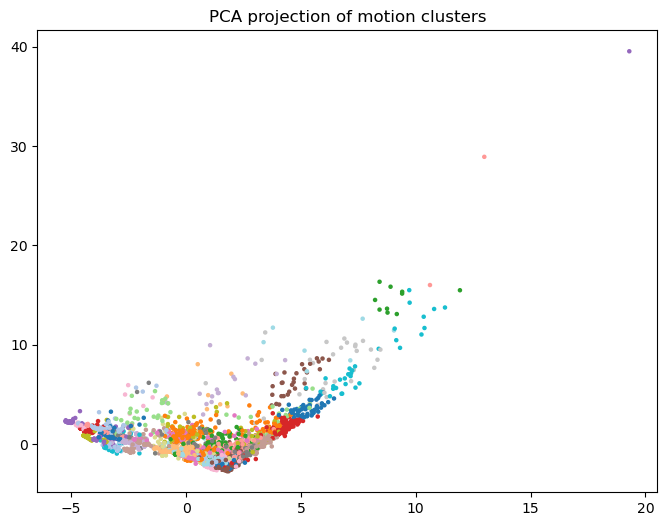

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# sample to keep plotting fast
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]
labels_sample = kmeans.predict(X_sample)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_sample, s=5, cmap='tab20')
plt.title("PCA projection of motion clusters")
plt.show()

In [10]:
cluster_counts = {i: {"adl":0, "fall":0} for i in range(K)}

for _, row in index_df.iterrows():
    feats = np.load(row["feature_path"])
    feats_scaled = scaler.transform(feats)
    tokens = kmeans.predict(feats_scaled)

    for t in tokens:
        cluster_counts[t][row["label_type"]] += 1

# inspect
for k_id, counts in cluster_counts.items():
    print(k_id, counts)

0 {'adl': 5289, 'fall': 1697}
1 {'adl': 11714, 'fall': 114}
2 {'adl': 1083, 'fall': 610}
3 {'adl': 5447, 'fall': 98}
4 {'adl': 0, 'fall': 955}
5 {'adl': 5233, 'fall': 544}
6 {'adl': 3104, 'fall': 185}
7 {'adl': 2647, 'fall': 845}
8 {'adl': 722, 'fall': 797}
9 {'adl': 0, 'fall': 229}
10 {'adl': 0, 'fall': 2}
11 {'adl': 7236, 'fall': 349}
12 {'adl': 12, 'fall': 198}
13 {'adl': 8, 'fall': 1104}
14 {'adl': 1397, 'fall': 502}
15 {'adl': 651, 'fall': 207}
16 {'adl': 3, 'fall': 672}
17 {'adl': 0, 'fall': 617}
18 {'adl': 2365, 'fall': 408}
19 {'adl': 1642, 'fall': 38}
20 {'adl': 2037, 'fall': 262}
21 {'adl': 3131, 'fall': 97}
22 {'adl': 4655, 'fall': 1}
23 {'adl': 0, 'fall': 53}
24 {'adl': 0, 'fall': 2111}
25 {'adl': 2150, 'fall': 6}
26 {'adl': 0, 'fall': 8}
27 {'adl': 0, 'fall': 431}
28 {'adl': 3253, 'fall': 671}
29 {'adl': 91, 'fall': 418}
30 {'adl': 7992, 'fall': 2233}
31 {'adl': 1900, 'fall': 1171}
32 {'adl': 14, 'fall': 683}
33 {'adl': 3079, 'fall': 481}
34 {'adl': 4796, 'fall': 8}
35 {'a